In [36]:
import pandas as pd


df = pd.read_csv('train.csv')

df.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [37]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [38]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

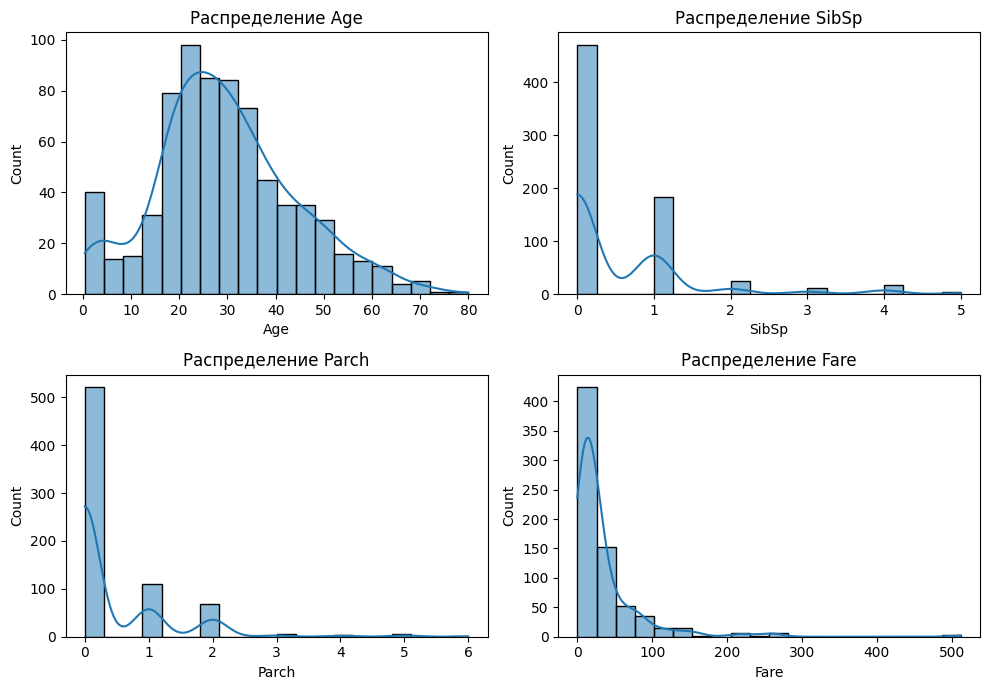

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns


df_w_age = df.dropna(subset=['Age'])
numeric_features = ['Age', 'SibSp', 'Parch', 'Fare']

fig, axes = plt.subplots(2, 2, figsize=(10, 7))
axes = axes.flatten()

for i, feature in enumerate(numeric_features):
    sns.histplot(df_w_age[feature], bins=20, kde=True, ax=axes[i])
    axes[i].set_title(f'Распределение {feature}')

plt.tight_layout()
plt.show()

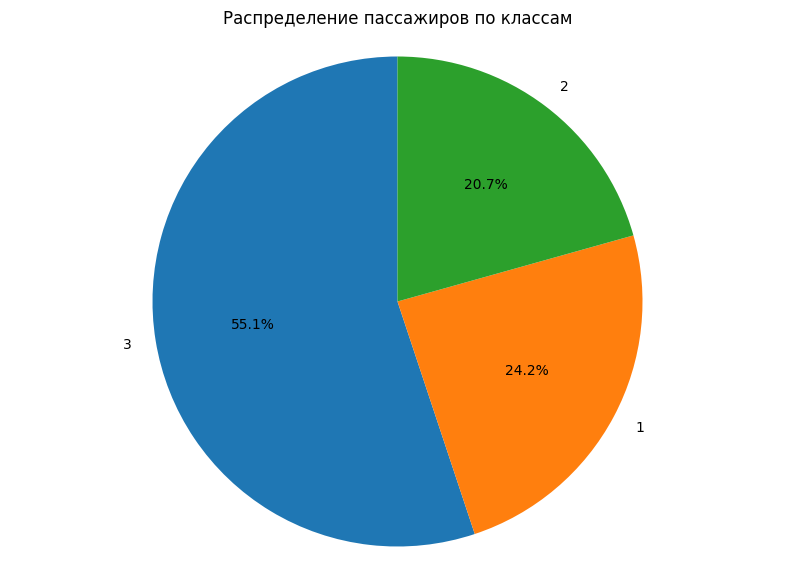

In [40]:
pclass_df = df['Pclass'].value_counts()

plt.figure(figsize=(10, 7))
plt.pie(pclass_df, labels=pclass_df.index, autopct='%1.1f%%', startangle=90)
plt.title('Распределение пассажиров по классам')
plt.axis('equal')
plt.show()

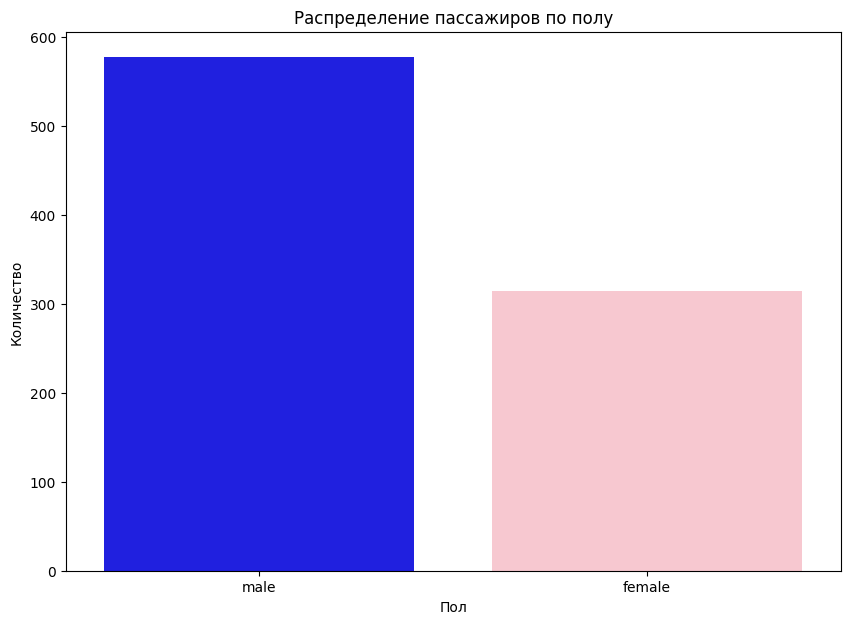

In [41]:
plt.figure(figsize=(10, 7))
sns.countplot(data=df, x='Sex', hue='Sex', palette=['blue', 'pink'], legend=False)
plt.title('Распределение пассажиров по полу')
plt.xlabel('Пол')
plt.ylabel('Количество')
plt.show()

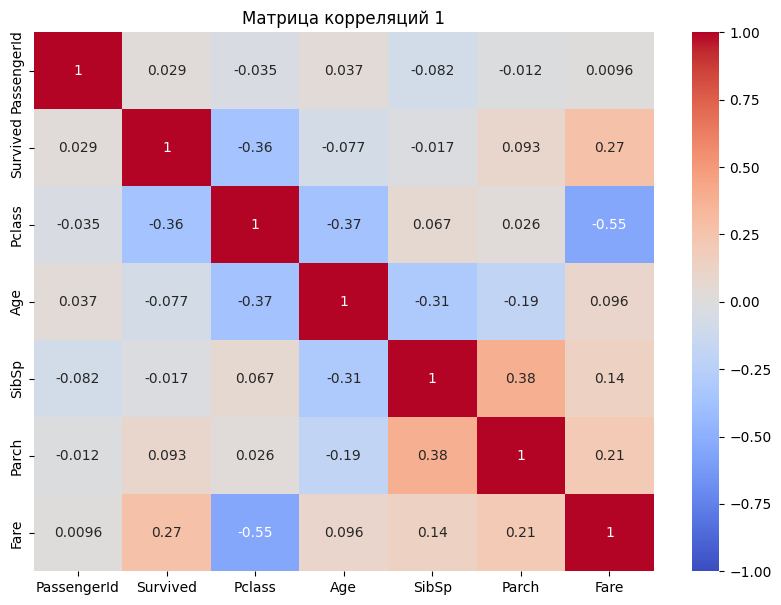

In [42]:
corr = df_w_age.select_dtypes(include=['float64', 'int64']).corr()

plt.figure(figsize=(10, 7))
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Матрица корреляций 1')
plt.show()

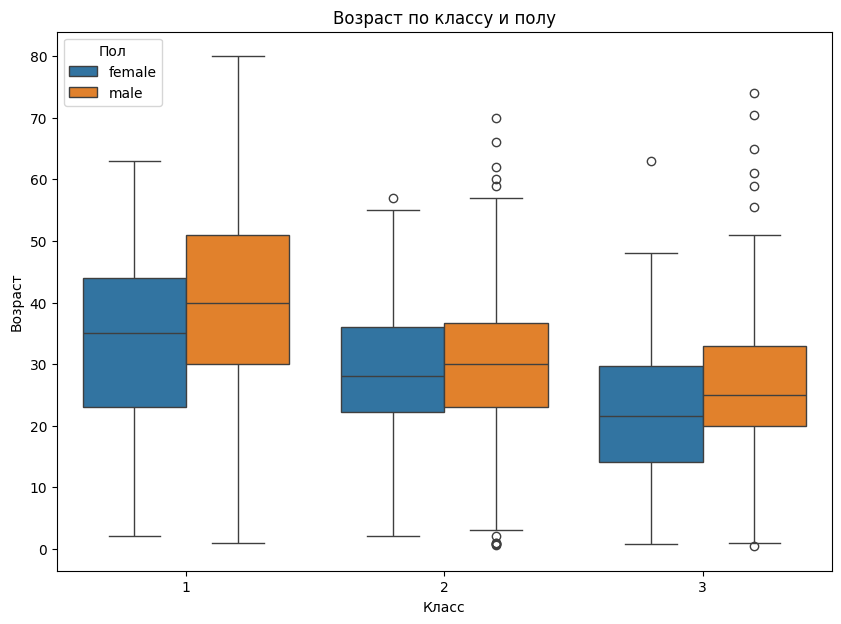

In [43]:
plt.figure(figsize=(10, 7))
sns.boxplot(x='Pclass', y='Age', hue='Sex', data=df_w_age)

plt.title('Возраст по классу и полу')
plt.xlabel('Класс')
plt.ylabel('Возраст')
plt.legend(title='Пол')
plt.show()

In [44]:
df['Age'] = df['Age'].fillna(df.groupby(['Pclass', 'Sex'])['Age'].transform('median'))

In [45]:
unique_cabins = df['Cabin'].dropna().to_numpy()

print(unique_cabins)

['C85' 'C123' 'E46' 'G6' 'C103' 'D56' 'A6' 'C23 C25 C27' 'B78' 'D33' 'B30'
 'C52' 'B28' 'C83' 'F33' 'F G73' 'C23 C25 C27' 'E31' 'A5' 'D10 D12' 'D26'
 'C110' 'B58 B60' 'E101' 'D26' 'F E69' 'D47' 'C123' 'B86' 'F2' 'C2' 'E33'
 'B19' 'A7' 'C49' 'F4' 'A32' 'F2' 'B4' 'B80' 'G6' 'A31' 'D36' 'D15' 'C93'
 'C83' 'C78' 'D35' 'G6' 'C87' 'B77' 'E67' 'B94' 'C125' 'C99' 'C118' 'D7'
 'A19' 'B49' 'D' 'C22 C26' 'C106' 'B58 B60' 'E101' 'C22 C26' 'C65' 'E36'
 'C54' 'B57 B59 B63 B66' 'C7' 'E34' 'C32' 'D' 'B18' 'C124' 'C91' 'C2'
 'E40' 'T' 'F2' 'C23 C25 C27' 'F33' 'C128' 'E33' 'D37' 'B35' 'E50' 'C82'
 'B96 B98' 'D36' 'G6' 'C78' 'E10' 'C52' 'E44' 'B96 B98' 'C23 C25 C27'
 'A34' 'C104' 'C111' 'C92' 'E38' 'D21' 'E12' 'E63' 'D' 'A14' 'B49' 'C93'
 'B37' 'C30' 'D20' 'C22 C26' 'B79' 'C65' 'E25' 'D46' 'F33' 'B73' 'B18'
 'C95' 'B38' 'B39' 'B22' 'C86' 'C70' 'A16' 'E67' 'C101' 'E25' 'E44' 'C68'
 'A10' 'E68' 'B41' 'D20' 'A20' 'C125' 'F4' 'D19' 'D50' 'D9' 'A23' 'B50'
 'B35' 'D33' 'A26' 'D48' 'E58' 'C126' 'B71' 'B51 B53 B

In [46]:
df['Deck'] = df['Cabin'].str.extract(r'^([A-Za-z])', expand=False).fillna('M')

In [47]:
df[['Cabin', 'Deck']]

,Cabin,Deck
0,NaN,M
1,C85,C
2,NaN,M
3,C123,C
4,NaN,M
...,...,...
886,NaN,M
887,B42,B
888,NaN,M
889,C148,C


In [48]:
df['Cab_count'] = df['Cabin'].str.count(r'[A-Z]\d+').fillna(0).astype(int)

In [49]:
df[df['Cabin'].notna()][['Cabin', 'Cab_count']].head(10)

,Cabin,Cab_count
1,C85,1
3,C123,1
6,E46,1
10,G6,1
11,C103,1
21,D56,1
23,A6,1
27,C23 C25 C27,3
31,B78,1
52,D33,1


In [50]:
df.drop(['Cabin'], axis=1, inplace=True)

In [51]:
df[df['Embarked'].isna()]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Deck,Cab_count
61,62,1,1,"Icard, Miss. Amelie",female,38.0,0,0,113572,80.0,NaN,B,1
829,830,1,1,"Stone, Mrs. George Nelson (Martha Evelyn)",female,62.0,0,0,113572,80.0,NaN,B,1
